# Data Overview

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Load Dataset

In [2]:
hurricanes = pd.read_csv("data/cleaned_hurricanes.csv") # renamed kaggle csv from storms to hurricane_data

### Inspect Dataset

In [3]:
print(hurricanes.head())
print(hurricanes.info())
print(hurricanes.columns)

                  name  year  month  day  hour   lat  long     status  \
0              Alberto  1982      6    3    18  24.0 -83.6  hurricane   
1              Alberto  1982      6    4     0  24.8 -83.4  hurricane   
2                Debby  1982      9   15     0  25.6 -71.0  hurricane   
3                Debby  1982      9   15    60  26.7 -70.3  hurricane   
4                Debby  1982      9   15    12  27.8 -69.6  hurricane   

   category  wind  ...  storm_id     correct_datetime             datetime  \
0       1.0    75  ...  AL011982  1982-06-03 18:00:00  1982-06-03 18:00:00   
1       1.0    65  ...  AL011982  1982-06-04 00:00:00  1982-06-04 00:00:00   
2       1.0    65  ...  AL061982  1982-09-15 00:00:00  1982-09-15 00:00:00   
3       1.0    65  ...  AL061982  1982-09-15 06:00:00  1982-09-15 06:00:00   
4       1.0    75  ...  AL061982  1982-09-15 12:00:00  1982-09-15 12:00:00   

    CSST  COHC   SHRD  RHMD   MTPW   VMPI    DTL  
0  277.0  67.0  294.0  51.0  541.0  111.0

NOTES: The dataset contains 3,883 hurricane observations with 25 variables describing storm characteristics, location, intensity, and environmental conditions. In addition to traditional hurricane attributes such as wind speed and pressure, the dataset includes SHIPS-derived meteorological and oceanographic variables that may improve prediction of hurricane intensity.

# EDA: Hurricane observations

### Summary Statistics

#### Hurricane Class Distribution

In [ ]:
# Hurricane Class Distribution
print("=== Hurricane Category Counts ===")
category_counts = hurricanes["category"].value_counts().sort_index()
print(category_counts)

print("\n=== Hurricane Category Percentages ===")
category_percentages = (
    hurricanes["category"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print(category_percentages.round(2))


print("\n=== Hurricane Class Counts ===")
class_counts = hurricanes["hurricane_class"].value_counts().sort_index()
print(class_counts)

print("\n=== Hurricane Class Percentages ===")
class_percentages = (
    hurricanes["hurricane_class"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print(class_percentages.round(2))

=== Hurricane Category Counts ===
category
1.0    2021
2.0     802
3.0     499
4.0     485
5.0      76
Name: count, dtype: int64

=== Hurricane Category Percentages ===
category
1.0    52.05
2.0    20.65
3.0    12.85
4.0    12.49
5.0     1.96
Name: proportion, dtype: float64

=== Hurricane Class Counts ===
hurricane_class
0    2823
1    1060
Name: count, dtype: int64

=== Hurricane Class Percentages ===
hurricane_class
0    72.7
1    27.3
Name: proportion, dtype: float64


NOTES:
Over half of the observations are Category 1 hurricanes, while Category 5 hurricanes are relatively rare.

Binary Classification Target - 27% of observations belong to the positive class, a model could appear to perform well by predicting the majority class most of the time. That makes evaluation metrics such as precision, recall, F1-score, and ROC-AUC more informative than accuracy alone.

The original hurricane categories are not evenly represented. Category 1 hurricanes account for just over half of all observations (52.05%), while Category 5 hurricanes represent fewer than 2% of the dataset. After grouping the storms into a binary classification problem, 72.7% of observations belong to the non-major hurricane class (Categories 1–2) and 27.3% belong to the major hurricane class (Categories 3–5). This moderate class imbalance should be considered during model development and evaluation, as accuracy alone may overestimate model performance.

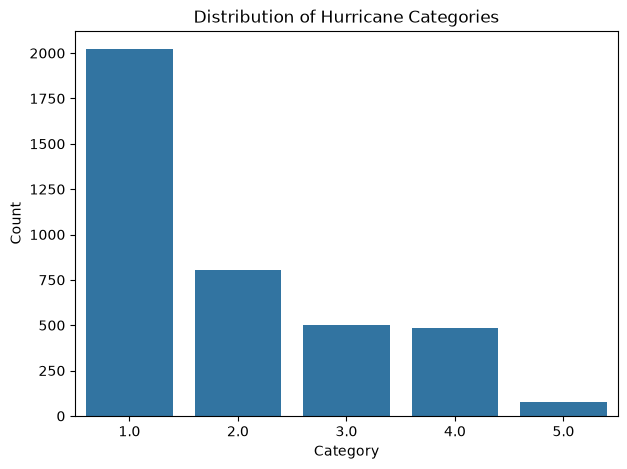

In [7]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=hurricanes,
    x="category",
    order=sorted(hurricanes["category"].unique())
)

plt.title("Distribution of Hurricane Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

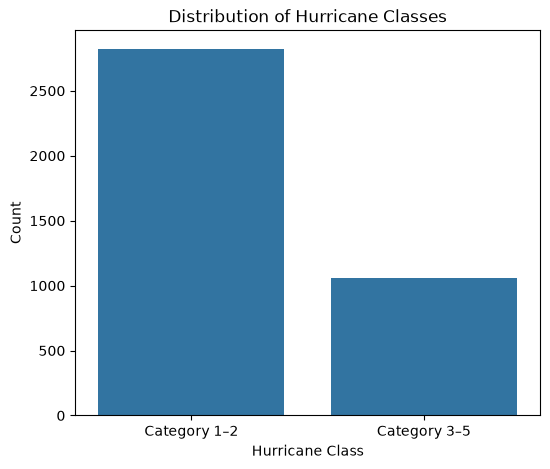

In [8]:
plt.figure(figsize=(6,5))
sns.countplot(
    data=hurricanes,
    x="hurricane_class"
)

plt.title("Distribution of Hurricane Classes")
plt.xlabel("Hurricane Class")
plt.ylabel("Count")
plt.xticks([0,1], ["Category 1–2","Category 3–5"])
plt.show()

#### Storm Characteristics Summary

In [9]:
# Storm Characteristics Summary
storm_vars = [
    "wind",
    "pressure",
    "tropicalstorm_force_diameter",
    "hurricane_force_diameter"
]

print("=== Storm Characteristic Summary ===")
display(hurricanes[storm_vars].describe())

=== Storm Characteristic Summary ===


,wind,pressure,tropicalstorm_force_diameter,hurricane_force_diameter
count,3883.000000,3883.000000,3883.000000,3883.000000
mean,87.015194,968.221221,250.699717,64.324749
std,20.389725,18.369406,99.661800,32.515290
min,65.000000,882.000000,50.000000,10.000000
25%,70.000000,956.000000,198.000000,45.000000
50%,80.000000,972.000000,229.000000,60.000000
75%,100.000000,983.000000,285.000000,75.000000
max,160.000000,1005.000000,870.000000,200.000000


NOTES: The storm characteristic variables describe the physical intensity and size of each hurricane. Wind speeds range from 65 to 160 knots, with an average of approximately 87 knots, indicating that the dataset contains hurricanes spanning from minimal hurricane strength through the strongest observed storms. Central pressure ranges from 882 to 1005 mb, with lower pressures generally corresponding to more intense hurricanes. The average tropical storm-force wind diameter is approximately 251 nautical miles, while the average hurricane-force wind diameter is approximately 64 nautical miles, suggesting substantial variation in storm size across observations. Overall, these variables capture the structural and intensity characteristics traditionally used to describe hurricanes.

#### SHIPS Metadata Summary

In [10]:
# SHIPS Metadata Summary
metadata_vars = [
    "CSST",
    "COHC",
    "SHRD",
    "RHMD",
    "MTPW",
    "VMPI",
    "DTL"
]

print("=== SHIPS Environmental Metadata Summary ===")
display(hurricanes[metadata_vars].describe())

=== SHIPS Environmental Metadata Summary ===


,CSST,COHC,SHRD,RHMD,MTPW,VMPI,DTL
count,3883.000000,3883.000000,3883.000000,3883.000000,3883.000000,3883.000000,3883.000000
mean,274.832346,35.637394,182.027298,53.448107,533.522792,118.491373,791.698944
std,18.914228,28.218144,102.550186,10.173385,67.852479,34.005244,602.036506
min,111.000000,0.000000,1.000000,23.000000,289.000000,0.000000,0.000000
25%,268.000000,11.000000,105.000000,46.000000,489.000000,103.000000,243.000000
50%,280.000000,34.000000,168.000000,53.000000,546.000000,129.000000,683.000000
75%,287.000000,56.000000,238.000000,60.000000,583.000000,142.000000,1257.000000
max,300.000000,141.000000,650.000000,87.000000,709.000000,183.000000,2431.000000


NOTES:
The merged dataset also includes seven environmental variables obtained from the Statistical Hurricane Intensity Prediction Scheme (SHIPS). These variables describe the atmospheric and oceanic conditions surrounding each storm, including sea surface temperature (CSST), ocean heat content (COHC), vertical wind shear (SHRD), relative humidity (RHMD), total precipitable water (MTPW), maximum potential intensity (VMPI), and distance to land (DTL). The summary statistics show considerable variability across these environmental conditions. For example, ocean heat content ranges from 0 to 141, vertical wind shear ranges from 1 to 650, and distance to land ranges from 0 to 2,431, indicating that storms developed under a wide variety of environmental settings. This variability suggests that these metadata variables may provide valuable predictive information beyond the traditional hurricane characteristics.

SHIPS Environmental Metadata

In addition to the traditional hurricane characteristics, this dataset includes environmental variables obtained from the **Statistical Hurricane Intensity Prediction Scheme (SHIPS)**. These variables describe the atmospheric and oceanic conditions surrounding each hurricane at the time of observation and provide additional information that may improve the prediction of hurricane intensity.

The SHIPS variables included in this study are summarized below:

| Variable | Description |
|----------|-------------|
| **CSST** | Climatological Sea Surface Temperature (0.1°C) |
| **COHC** | Ocean Heat Content (kJ/cm²) |
| **SHRD** | Vertical Wind Shear (knots) |
| **RHMD** | Mid-level Relative Humidity (%) |
| **MTPW** | Mean Total Precipitable Water (mm) |
| **VMPI** | Maximum Potential Intensity (knots) |
| **DTL** | Distance to Land (km) |

These environmental variables complement the traditional storm characteristics (such as wind speed and pressure) by capturing oceanic and atmospheric conditions that influence hurricane development and intensification. Their distributions are explored in the following sections to better understand the variability of the environmental conditions represented in the dataset.

### Distribution Analysis

#### Traditional Storm Variables

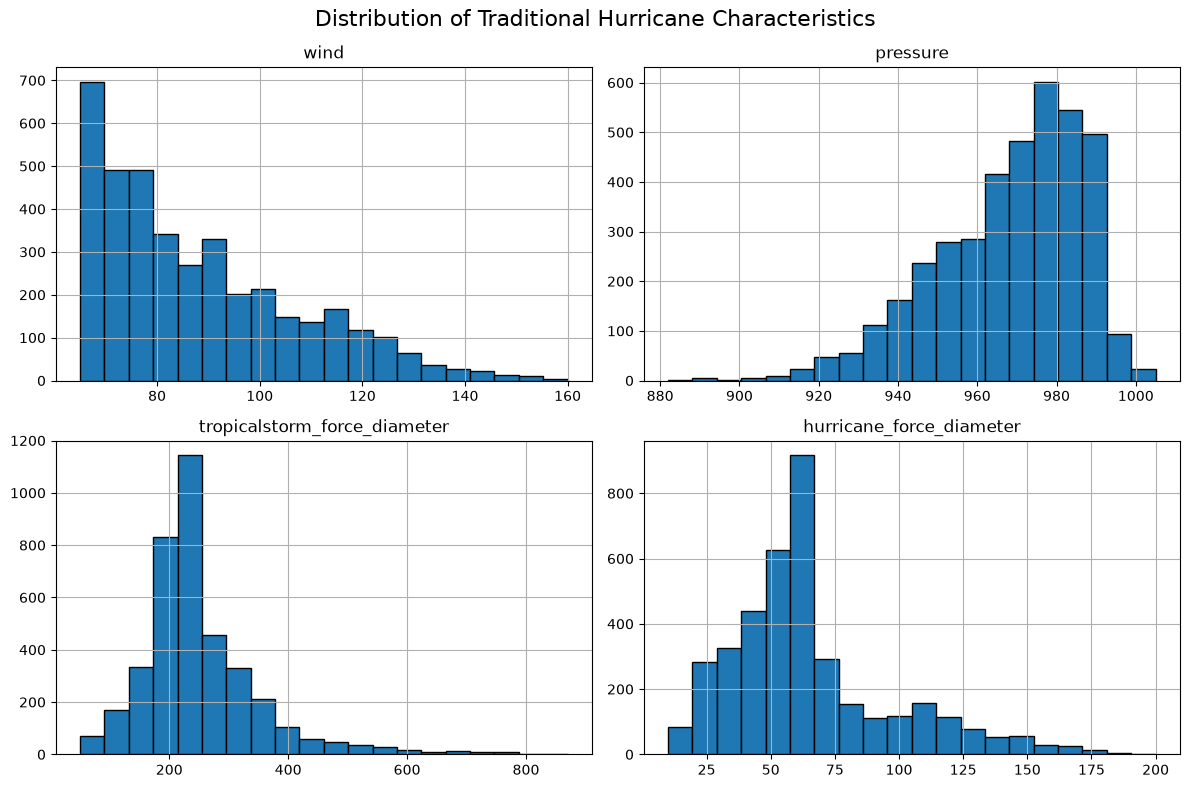

In [12]:
storm_vars = [
    "wind",
    "pressure",
    "tropicalstorm_force_diameter",
    "hurricane_force_diameter"
]

hurricanes[storm_vars].hist(
    bins=20,
    figsize=(12,8),
    edgecolor="black"
)

plt.suptitle("Distribution of Traditional Hurricane Characteristics", fontsize=16)
plt.tight_layout()
plt.show()

NOTES:
Wind
* Right-skewed.
* Most storms are clustered around 65–90 knots.
* Very few Category 4–5 hurricanes (140–160 knots).

Pressure
* Fairly symmetric.
* Slight left skew because stronger hurricanes have much lower pressures.
* No obvious data quality issues.

Tropical Storm Diameter
* Moderately right-skewed.
* Majority between roughly 175–300 nautical miles.
* A handful of unusually large storms.

Tropical Storm Diameter
* Moderately right-skewed.
* Majority between roughly 175–300 nautical miles.
* A handful of unusually large storms.

Overall
* Most hurricanes are weaker storms.
* Only a small proportion are very intense.
* Storm size varies considerably.
* A few extreme hurricanes produce the long right tails.

#### SHIPS Environmental Variables

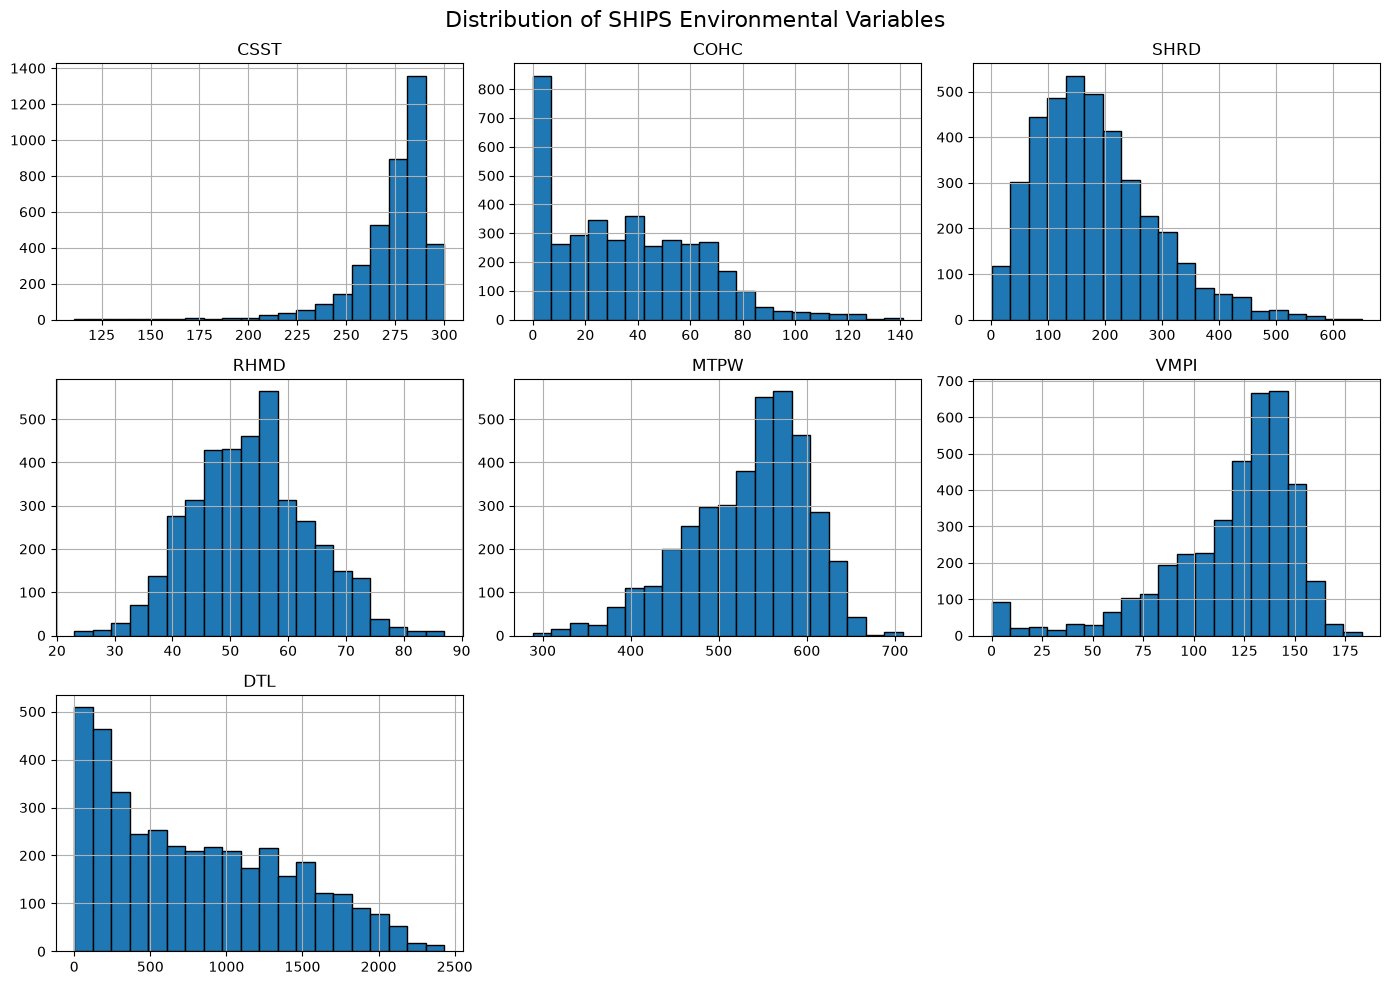

In [13]:
metadata_vars = [
    "CSST",
    "COHC",
    "SHRD",
    "RHMD",
    "MTPW",
    "VMPI",
    "DTL"
]

hurricanes[metadata_vars].hist(
    bins=20,
    figsize=(14,10),
    edgecolor="black"
)

plt.suptitle("Distribution of SHIPS Environmental Variables", fontsize=16)
plt.tight_layout()
plt.show()

NOTES:

CSST
* Most observations are concentrated between 270–295.
* Strong left (negative) skew.
* Very few hurricanes occur over cooler water.
* Most hurricanes in the dataset formed over relatively warm ocean waters, which is consistent with the environmental conditions required for hurricane development.

COHC

* Highly right-skewed.
* Large concentration near lower values with a long tail extending above 100.
* Ocean heat content varies considerably among storms, indicating that hurricanes encountered a broad range of available ocean energy.

SHRD

* Moderately right-skewed.
* Most observations between roughly 75 and 250.
* Most hurricanes experienced relatively low to moderate vertical wind shear, while only a small number developed in environments with very high shear.

RHMD
* Approximately symmetric.
* Bell-shaped distribution.
* Mid-level relative humidity is relatively consistent across observations and appears to be the closest variable to a normal distribution.

MTPW
* Slight negative skew.
* Concentrated around 500–600.
* Hurricanes generally occurred in moisture-rich environments, with relatively few observations in dry atmospheric conditions.

VMPI
* Moderate negative skew.
* Majority between 120–150.
* Many storms occurred in environments capable of supporting high theoretical hurricane intensity, although some storms developed under less favorable conditions.

DTL
* Strong right skew.
* Large number of observations close to land with a long tail extending to approximately 2,400.
* Hurricanes were observed at a wide range of distances from land, from landfall or near-coastal locations to storms located far over the open ocean.

#### Correlation Analysis

In [14]:
predictor_vars = [
    "wind",
    "pressure",
    "tropicalstorm_force_diameter",
    "hurricane_force_diameter",
    "lat",
    "long",
    "month",
    "day",
    "hour",
    "CSST",
    "COHC",
    "SHRD",
    "RHMD",
    "MTPW",
    "VMPI",
    "DTL",
    "hurricane_class"
]

corr_df = hurricanes[predictor_vars]

In [15]:
correlation_matrix = corr_df.corr(numeric_only=True)

correlation_matrix

,wind,pressure,tropicalstorm_force_diameter,hurricane_force_diameter,lat,long,month,day,hour,CSST,COHC,SHRD,RHMD,MTPW,VMPI,DTL,hurricane_class
wind,1.000000,-0.906436,0.055328,0.351772,-0.299187,-0.163610,-0.000768,-0.077087,0.007070,0.329328,0.385157,-0.214782,0.217054,0.367806,0.278675,-0.211188,0.848930
pressure,-0.906436,1.000000,-0.245139,-0.499559,0.153910,0.202796,-0.029144,0.056107,-0.007197,-0.255276,-0.318842,0.132368,-0.197799,-0.381819,-0.165707,0.221248,-0.772200
tropicalstorm_force_diameter,0.055328,-0.245139,1.000000,0.772446,0.367424,-0.017460,0.155832,0.117153,0.001305,-0.324918,-0.185292,0.261733,-0.129930,-0.100198,-0.355670,-0.029694,0.049103
hurricane_force_diameter,0.351772,-0.499559,0.772446,1.000000,0.261048,-0.164394,0.070804,0.094545,0.001741,-0.072108,0.005627,0.143592,-0.064672,0.065234,-0.174562,-0.146040,0.274999
lat,-0.299187,0.153910,0.367424,0.261048,1.000000,0.085718,0.009341,0.017503,-0.007628,-0.625604,-0.620699,0.426882,-0.512765,-0.617437,-0.668734,0.184713,-0.285677
long,-0.163610,0.202796,-0.017460,-0.164394,0.085718,1.000000,0.020440,0.040666,-0.000811,-0.502719,-0.524518,0.036221,-0.325390,-0.432113,-0.294596,0.810067,-0.142205
month,-0.000768,-0.029144,0.155832,0.070804,0.009341,0.020440,1.000000,-0.208167,0.003255,-0.162013,-0.048542,0.185603,-0.047173,-0.142356,0.003537,0.051826,0.010065
day,-0.077087,0.056107,0.117153,0.094545,0.017503,0.040666,-0.208167,1.000000,0.002379,-0.020246,-0.034981,0.008202,-0.018874,-0.043167,-0.006866,0.055997,-0.087995
hour,0.007070,-0.007197,0.001305,0.001741,-0.007628,-0.000811,0.003255,0.002379,1.000000,0.004629,0.002734,-0.043624,0.021399,0.001288,-0.018009,-0.001379,0.006249
CSST,0.329328,-0.255276,-0.324918,-0.072108,-0.625604,-0.502719,-0.162013,-0.020246,0.004629,1.000000,0.716313,-0.387468,0.395747,0.683007,0.793287,-0.419276,0.293011


NOTES:

Wind speed has the strongest positive relationship with hurricane class (r = 0.849), while central pressure has the strongest negative relationship (r = -0.772). These findings are expected because stronger hurricanes are characterized by higher sustained winds and lower central pressures. Among the environmental variables, COHC, MTPW, CSST, and VMPI exhibit moderate positive correlations with hurricane class, suggesting that warmer oceans, greater atmospheric moisture, and higher potential intensity are associated with an increased likelihood of major hurricanes. Conversely, SHRD and DTL demonstrate modest negative correlations, indicating that stronger vertical wind shear and greater distance-related environmental effects are generally associated with weaker storms.

Environmental Variables
Several SHIPS environmental variables demonstrate moderate to strong correlations with one another, particularly CSST, COHC, VMPI, MTPW, and RHMD. These relationships are expected because these variables describe related oceanic and atmospheric conditions that influence hurricane development. The presence of correlated predictors suggests that multicollinearity may exist within the environmental metadata, making feature selection an important step before model development.

Geographic Variables
Latitude exhibits moderate negative correlations with several environmental variables, including CSST, COHC, MTPW, and VMPI, indicating that hurricanes at higher latitudes generally experience cooler ocean temperatures and less favorable environmental conditions for intensification.

Tropical Storm Diameter
has almost no relationship with hurricane class (r = 0.049). That suggests storm size alone is not a good indicator of whether a hurricane is classified as major.


The correlation analysis highlights several important findings that motivate the subsequent feature selection analysis. Wind speed and central pressure remain the strongest predictors of hurricane intensity, while multiple SHIPS environmental variables—including ocean heat content, total precipitable water, sea surface temperature, and maximum potential intensity—demonstrate meaningful relationships with the target variable. In contrast, variables such as tropical storm-force wind diameter exhibit little association with hurricane intensity. The presence of moderate to strong correlations among several environmental variables also suggests potential multicollinearity, reinforcing the need for formal feature selection to identify the most informative subset of predictors for predictive modeling.

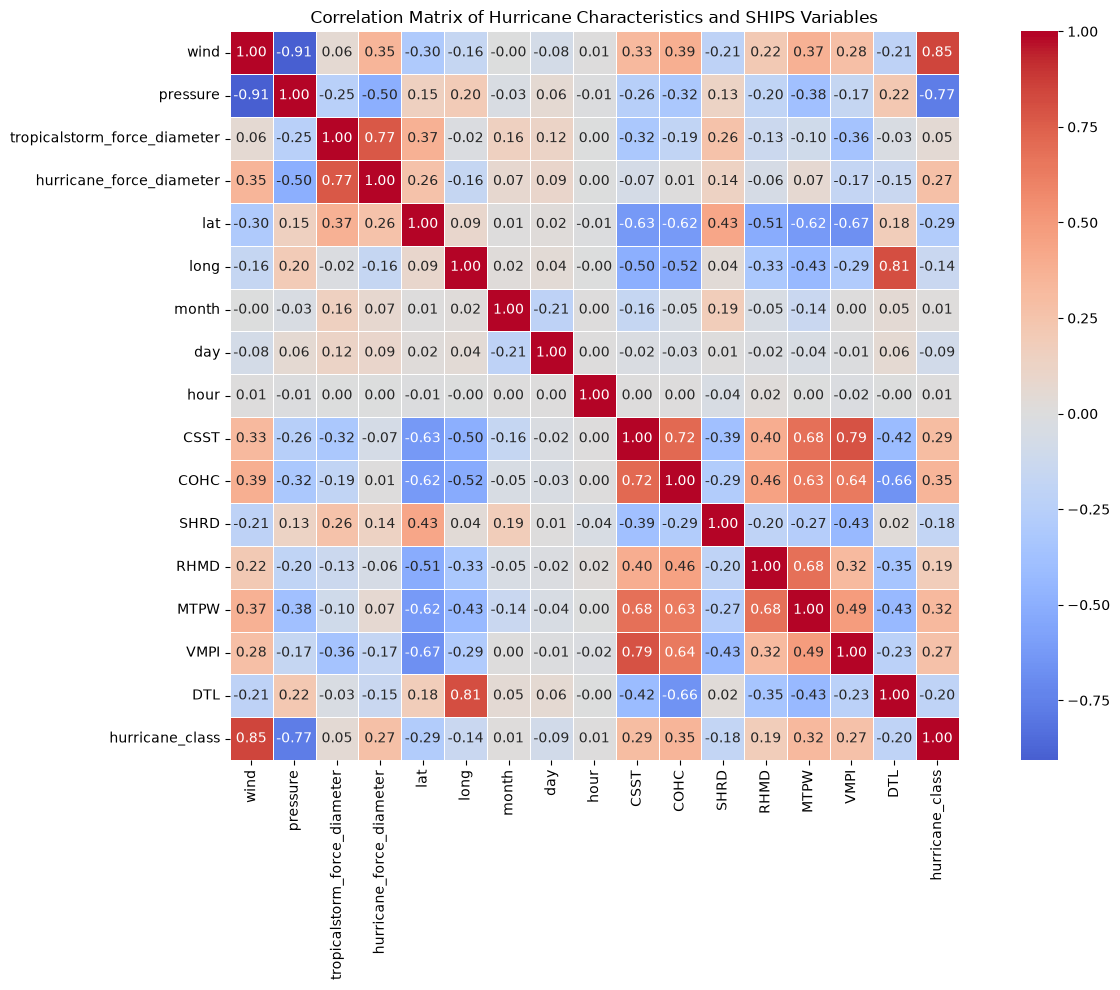

In [21]:
plt.figure(figsize=(14,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix of Hurricane Characteristics and SHIPS Variables")
plt.tight_layout()
plt.show()

In [25]:
target_corr = (
    correlation_matrix["hurricane_class"]
    .sort_values(ascending=False)
)

display(target_corr)

hurricane_class                 1.000000
wind                            0.848930
COHC                            0.351433
MTPW                            0.323569
CSST                            0.293011
hurricane_force_diameter        0.274999
VMPI                            0.266935
RHMD                            0.185495
tropicalstorm_force_diameter    0.049103
month                           0.010065
hour                            0.006249
day                            -0.087995
long                           -0.142205
SHRD                           -0.182214
DTL                            -0.201504
lat                            -0.285677
pressure                       -0.772200
Name: hurricane_class, dtype: float64

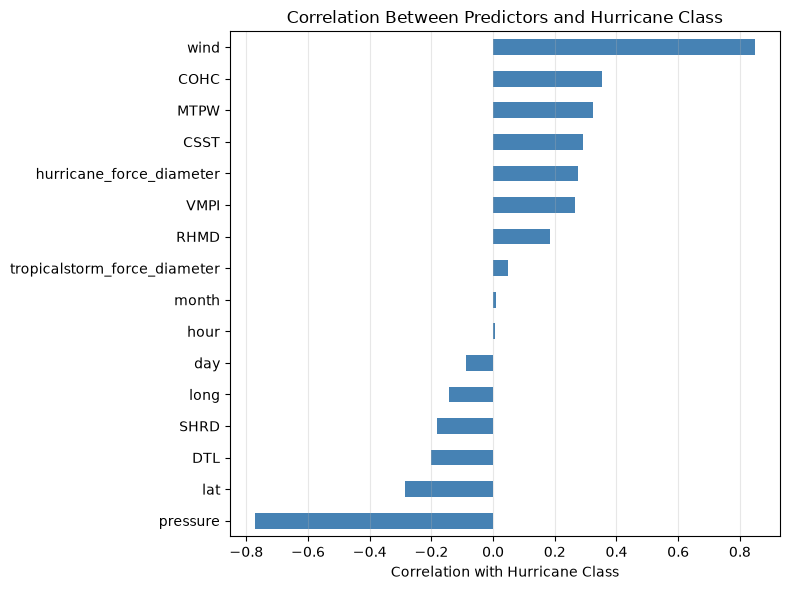

In [26]:
target_corr = target_corr.drop("hurricane_class")

plt.figure(figsize=(8,6))

target_corr.sort_values().plot(
    kind="barh",
    color="steelblue"
)

plt.xlabel("Correlation with Hurricane Class")
plt.title("Correlation Between Predictors and Hurricane Class")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/wz/29tjx61923s_d1p75gmh2qfw0000gn/T/ipykernel_58558/671239176.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(["Cat 1-2","Cat 3-5"])
/var/folders/wz/29tjx61923s_d1p75gmh2qfw0000gn/T/ipykernel_58558/671239176.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(["Cat 1-2","Cat 3-5"])
/var/folders/wz/29tjx61923s_d1p75gmh2qfw0000gn/T/ipykernel_58558/671239176.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(["Cat 1-2","Cat 3-5"])
/var/folders/wz/29tjx61923s_d1p75gmh2qfw0000gn/T/ipykernel_58558/671239176.py:21: UserWarning: set_ticklabels() sho

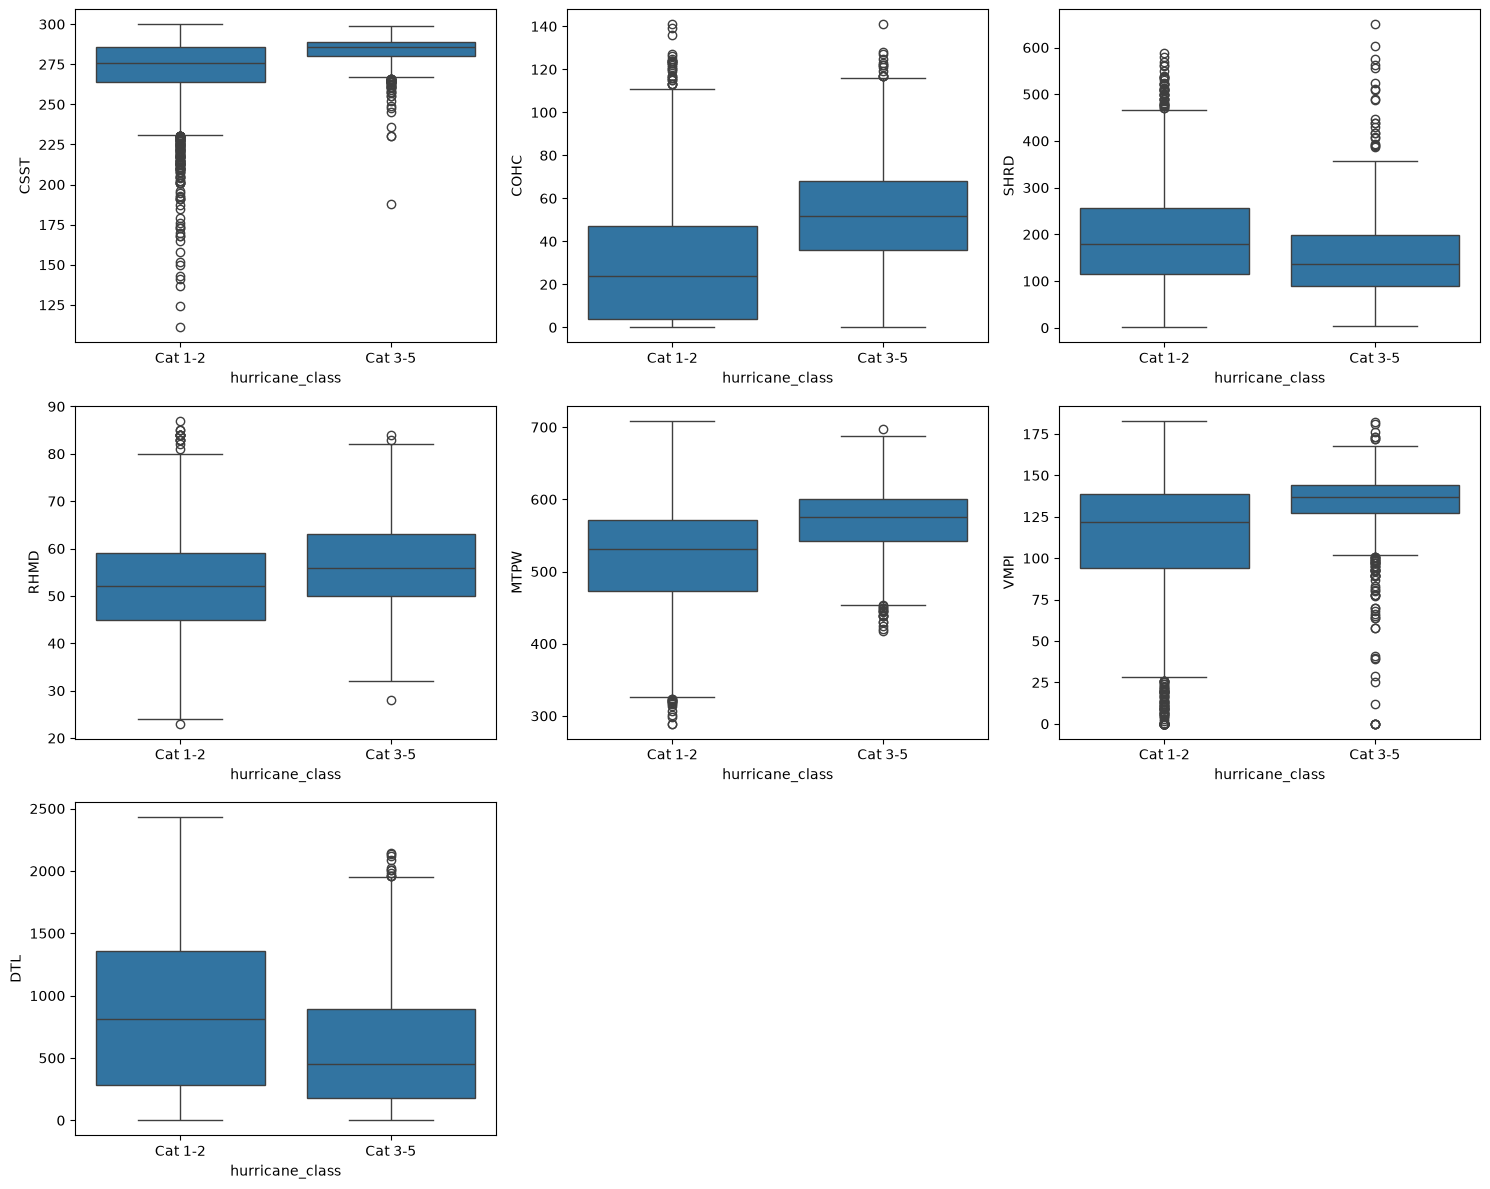

In [27]:
metadata_vars = [
    "CSST",
    "COHC",
    "SHRD",
    "RHMD",
    "MTPW",
    "VMPI",
    "DTL"
]

fig, axes = plt.subplots(3, 3, figsize=(15,12))
axes = axes.flatten()

for i, var in enumerate(metadata_vars):
    sns.boxplot(
        data=hurricanes,
        x="hurricane_class",
        y=var,
        ax=axes[i]
    )
    axes[i].set_xticklabels(["Cat 1-2","Cat 3-5"])

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

NOTES:
CSST (Sea Surface Temperature)
The median sea surface temperature is noticeably higher for major hurricanes.
* Category 3–5 storms occur over warmer water.
* Some overlap exists, but the shift in the median is clear.

COHC (Ocean Heat Content)
Major hurricanes show:
* much higher median COHC
* higher upper quartiles
* greater variability

SHRD (Vertical Wind Shear)
Major hurricanes generally experience:
* lower wind shear
* smaller median SHRD

RHMD (Relative Humidity)
Major hurricanes occur in:
* slightly more humid environments

MTPW (Total Precipitable Water)
Major hurricanes generally occur in environments with:
* higher atmospheric moisture
* higher median values
* tighter distribution

VMPI (Maximum Potential Intensity)
Major hurricanes occur in environments capable of supporting much greater theoretical intensity.


DTL (Distance to Land)
Major hurricanes generally have lower median distance to land.

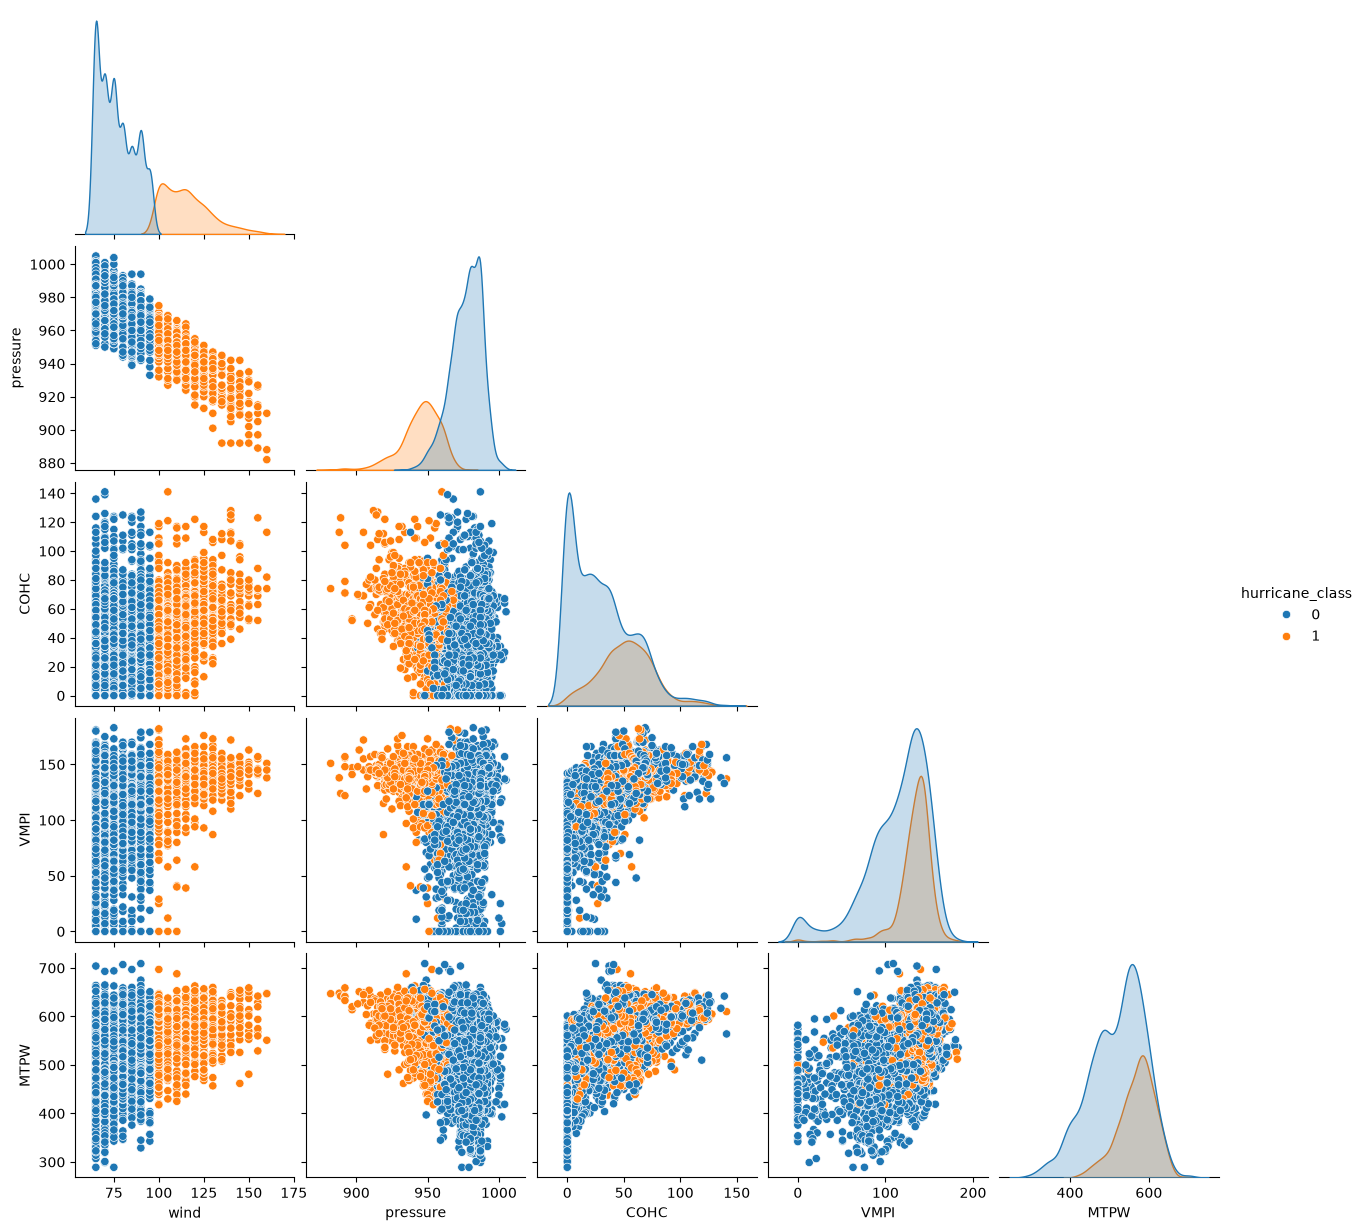

In [28]:
pairplot_vars = [
    "wind",
    "pressure",
    "COHC",
    "VMPI",
    "MTPW",
    "hurricane_class"
]

sns.pairplot(
    hurricanes[pairplot_vars],
    hue="hurricane_class",
    corner=True
)

NOTES:

Wind
* Wind exhibits the strongest positive correlation with hurricane class (r = 0.849).
* Major hurricanes are concentrated at higher wind speeds, generally above 95–100 knots.
* Non-major hurricanes are concentrated between 65 and 90 knots.
* Wind provides the clearest visual separation between the two classes.

Pressure
* Pressure has a strong negative correlation with hurricane class (r = -0.772).
* Major hurricanes are concentrated at lower central pressures, typically below 960 mb.
* Non-major hurricanes generally occur between 970 and 1000 mb.
* Wind and pressure show a very strong inverse relationship (r = -0.906).

COHC (Ocean Heat Content)
* COHC has the strongest correlation among the SHIPS variables with hurricane class (r = 0.351).
* Major hurricanes are concentrated at COHC values between approximately 40 and 80.
* Non-major hurricanes occur across the full range but are more common below 40.
* COHC has a moderate positive relationship with VMPI (r = 0.637) and CSST (r = 0.716).

VMPI (Maximum Potential Intensity)
* VMPI has a moderate positive correlation with hurricane class (r = 0.267).
* Major hurricanes are concentrated at VMPI values above approximately 130 knots.
* VMPI is strongly correlated with CSST (r = 0.793), suggesting warmer waters support greater potential hurricane intensity.
* The classes overlap, but the median for major hurricanes is clearly higher.

MTPW (Total Precipitable Water)
* MTPW has a moderate positive correlation with hurricane class (r = 0.324).
* Major hurricanes tend to occur where MTPW exceeds approximately 550.
* MTPW is positively correlated with RHMD (r = 0.684) and COHC (r = 0.631).
* Although overlap exists, major hurricanes generally occur in more moisture-rich environments.

Wind vs. Pressure
* Wind and pressure exhibit the strongest relationship in the dataset (r = -0.906).
* Higher wind speeds correspond directly with lower central pressures.
* Major hurricanes occupy the high-wind, low-pressure region of the scatterplot.
* This relationship reflects the well-established physical structure of stronger hurricanes.

Wind vs. COHC
* Wind and COHC show a moderate positive relationship (r = 0.385).
* Higher wind speeds tend to occur under greater ocean heat content.
* Major hurricanes cluster in the upper-right portion of the plot.
* Considerable overlap suggests COHC complements, rather than replaces, wind as a predictor.

Wind vs. VMPI
* Wind and VMPI have a moderate positive correlation (r = 0.279).
* Higher wind speeds generally occur in environments with higher potential intensity.
* Major hurricanes are concentrated at both higher wind speeds and higher VMPI values.
* The relationship supports VMPI as a useful environmental predictor.

Wind vs. MTPW
* Wind and MTPW exhibit a moderate positive relationship (r = 0.368).
* Major hurricanes are more common in high-moisture environments.
* Non-major hurricanes occupy a broader range of MTPW values.
* Atmospheric moisture appears to contribute to storm intensification.

Pressure vs. COHC
* Pressure and COHC exhibit a moderate negative correlation (r = -0.319).
* Lower pressures are generally associated with higher ocean heat content.
* Major hurricanes occupy the low-pressure, high-COHC region.
* The scatterplot indicates that ocean energy supports stronger storms.

Pressure vs. VMPI
* Pressure and VMPI have a weak-to-moderate negative correlation (r = -0.166).
* Major hurricanes are concentrated where pressure is lowest and VMPI is highest.
* The relationship is weaker than that observed for wind and pressure but remains physically meaningful.

Pressure vs. MTPW
* Pressure and MTPW exhibit a moderate negative relationship (r = -0.382).
* Lower pressure systems generally occur in environments with greater atmospheric moisture.
* Major hurricanes are clustered in the low-pressure, high-MTPW region.

COHC vs. VMPI
* COHC and VMPI show a strong positive correlation (r = 0.637).
* Higher ocean heat content is associated with greater potential hurricane intensity.
* Major hurricanes are concentrated where both variables are relatively high.
* This relationship suggests these variables describe complementary aspects of favorable ocean conditions.


COHC vs. MTPW
* COHC and MTPW exhibit a strong positive relationship (r = 0.631).
* Higher ocean heat content is generally accompanied by higher atmospheric moisture.
* Major hurricanes are concentrated in the upper-right region of the plot.
* The variables likely capture related environmental processes that promote storm intensification.

VMPI vs. MTPW
* VMPI and MTPW show a moderate positive correlation (r = 0.492).
* Higher potential intensity is associated with more moisture-rich environments.
* Major hurricanes are concentrated where both variables are elevated.
* The overlap between classes suggests that multiple favorable environmental conditions are needed to support hurricane intensification.

### Key Exploratory Findings

EDA Summary

* The dataset contains 3,883 hurricane observations and 25 variables with no missing values.
* The target variable is moderately imbalanced, with 72.7% non-major hurricanes and 27.3% major hurricanes.
* Wind speed and central pressure exhibit the strongest relationships with hurricane class.
* SHIPS environmental variables, particularly COHC, MTPW, and VMPI, show moderate associations with hurricane intensity and provide complementary environmental information.
* Several SHIPS variables are moderately correlated with one another, suggesting some multicollinearity that should be considered during feature selection.
* Overall, the EDA indicates that both traditional storm characteristics and environmental metadata are likely to contribute to classification performance and justify proceeding to feature selection.